In [ ]:
# Fix NumPy binary incompatibility issue
import subprocess
import sys

print("🔧 Fixing NumPy binary compatibility...")
print("This error occurs when packages were compiled against different NumPy versions")

# List of packages that need to be reinstalled after NumPy change
numpy_dependent_packages = [
    'numpy==1.24.4',
    'matplotlib',
    'opencv-python',
    'scikit-image', 
    'scikit-learn',
    'pillow',
    'seaborn'
]

print(f"\n📦 Reinstalling {len(numpy_dependent_packages)} packages...")

try:
    # First, uninstall problematic packages
    print("🗑️  Uninstalling old versions...")
    subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", 
                          "numpy", "matplotlib", "opencv-python", "scikit-image", 
                          "scikit-learn", "seaborn"])
    
    # Now reinstall everything fresh
    print("📦 Installing fresh versions...")
    for package in numpy_dependent_packages:
        print(f"  Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--no-cache-dir"])
        print(f"  ✅ {package} installed")
    
    print("\n🎉 All packages reinstalled successfully!")
    print("🔄 IMPORTANT: Restart the kernel now!")
    print("   Go to Kernel → Restart Kernel in Jupyter Lab")
    
except Exception as e:
    print(f"❌ Error during reinstallation: {e}")
    print("\n💡 Manual fix - run this in terminal:")
    print("pip uninstall -y numpy matplotlib opencv-python scikit-image scikit-learn seaborn")
    print("pip install numpy==1.24.4 matplotlib opencv-python scikit-image scikit-learn seaborn --no-cache-dir")

In [ ]:
# Import all required libraries
import boto3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ExifTags
import io
import cv2
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("📦 All libraries imported successfully!")
print("🎨 Ready for image analysis!")

In [ ]:
# Setup MinIO connection
s3_client = boto3.client(
    's3',
    endpoint_url='http://minio:9000',  # Docker network name
    aws_access_key_id='minioadmin',
    aws_secret_access_key=os.getenv('MINIO_SECRET_KEY'),
    region_name='us-east-1'
)

print("🔗 Connecting to MinIO...")

try:
    # List available buckets
    buckets = s3_client.list_buckets()
    print("✅ Connected successfully!")
    print("\n📁 Available buckets:")
    
    for bucket in buckets['Buckets']:
        print(f"  • {bucket['Name']}")
        
        # List files in each bucket
        try:
            response = s3_client.list_objects_v2(Bucket=bucket['Name'])
            if 'Contents' in response:
                print(f"    📄 Files in {bucket['Name']}:")
                for obj in response['Contents'][:5]:  # Show first 5 files
                    print(f"      - {obj['Key']} ({obj['Size']} bytes)")
                if len(response['Contents']) > 5:
                    print(f"      ... and {len(response['Contents']) - 5} more files")
            else:
                print(f"    📭 Empty bucket")
        except Exception as e:
            print(f"    ❌ Error listing bucket: {e}")
    
except Exception as e:
    print(f"❌ Error connecting to MinIO: {e}")
    print("💡 Make sure MinIO is running on localhost:9000")

In [ ]:
# Automatically detect and load the first image found
BUCKET_NAME = None
IMAGE_KEY = None

# Find the first image in any bucket
image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.gif', '.webp']

print("🔍 Searching for images in all buckets...")

try:
    buckets = s3_client.list_buckets()
    
    for bucket in buckets['Buckets']:
        bucket_name = bucket['Name']
        
        try:
            response = s3_client.list_objects_v2(Bucket=bucket_name)
            if 'Contents' in response:
                for obj in response['Contents']:
                    file_key = obj['Key']
                    if any(file_key.lower().endswith(ext) for ext in image_extensions):
                        BUCKET_NAME = bucket_name
                        IMAGE_KEY = file_key
                        print(f"🎯 Found image: {bucket_name}/{file_key}")
                        break
                        
            if BUCKET_NAME and IMAGE_KEY:
                break
                
        except Exception as e:
            continue
    
    if not BUCKET_NAME or not IMAGE_KEY:
        print("❌ No images found in any bucket!")
        print("💡 Please upload an image to a MinIO bucket first")
    else:
        print(f"✅ Will analyze: {BUCKET_NAME}/{IMAGE_KEY}")
        
except Exception as e:
    print(f"❌ Error searching for images: {e}")

# You can also manually set these values:
# BUCKET_NAME = "your-bucket-name"
# IMAGE_KEY = "your-image-file.jpg"

In [ ]:
# Load and display the image
if BUCKET_NAME and IMAGE_KEY:
    try:
        print(f"📥 Loading image from {BUCKET_NAME}/{IMAGE_KEY}...")
        
        # Download image from MinIO
        response = s3_client.get_object(Bucket=BUCKET_NAME, Key=IMAGE_KEY)
        image_data = response['Body'].read()
        
        # Load with PIL
        pil_img = Image.open(io.BytesIO(image_data))
        
        # Convert to numpy array
        img_array = np.array(pil_img)
        
        print(f"✅ Image loaded successfully!")
        print(f"📏 Dimensions: {pil_img.size[0]} × {pil_img.size[1]} pixels")
        print(f"🎨 Mode: {pil_img.mode}")
        print(f"💾 File size: {len(image_data):,} bytes")
        
        # Display the image
        plt.figure(figsize=(10, 8))
        plt.imshow(img_array)
        plt.title(f"📸 Original Image: {IMAGE_KEY}", fontsize=14, pad=20)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error loading image: {e}")
        pil_img = None
        img_array = None
        
else:
    print("⚠️ No image to load. Please run the previous cell to detect images.")
    pil_img = None
    img_array = None

In [ ]:
# Basic Image Analysis
if pil_img is not None:
    print("🔍 BASIC IMAGE PROPERTIES")
    print("=" * 40)
    
    width, height = pil_img.size
    total_pixels = width * height
    
    print(f"📐 Dimensions: {width} × {height} pixels")
    print(f"📊 Total pixels: {total_pixels:,}")
    print(f"🎨 Color mode: {pil_img.mode}")
    print(f"🗜️  Format: {pil_img.format or 'Unknown'}")
    print(f"💾 File size: {len(image_data):,} bytes ({len(image_data)/1024:.1f} KB)")
    
    # Analyze color channels
    if len(img_array.shape) == 3:
        channels = img_array.shape[2]
        print(f"🌈 Color channels: {channels}")
        print(f"📊 Array shape: {img_array.shape}")
        print(f"🔢 Data type: {img_array.dtype}")
        print(f"📈 Pixel value range: {img_array.min()} - {img_array.max()}")
    else:
        print(f"⚫ Grayscale image")
        print(f"📊 Array shape: {img_array.shape}")
        print(f"🔢 Data type: {img_array.dtype}")
        print(f"📈 Pixel value range: {img_array.min()} - {img_array.max()}")
    
    # Calculate aspect ratio
    aspect_ratio = width / height
    print(f"\n📏 Aspect ratio: {aspect_ratio:.2f}:1")
    
    if abs(aspect_ratio - 1.0) < 0.1:
        print("   → Nearly square image")
    elif aspect_ratio > 1.5:
        print("   → Landscape orientation")
    elif aspect_ratio < 0.67:
        print("   → Portrait orientation")
    else:
        print("   → Standard rectangular format")
        
else:
    print("❌ No image loaded for analysis")

🎨 COLOR ANALYSIS
🔍 Debug - Image array shape: (402, 402, 3)
🔍 Debug - PIL image mode: RGBA
🔍 Debug - mean_colors shape: (3,)
🔍 Debug - mean_colors values: [96.54687384 87.53278384 67.92609094]
🔴 Red   - Mean: 96.5
🟢 Green - Mean: 87.5
🔵 Blue  - Mean: 67.9


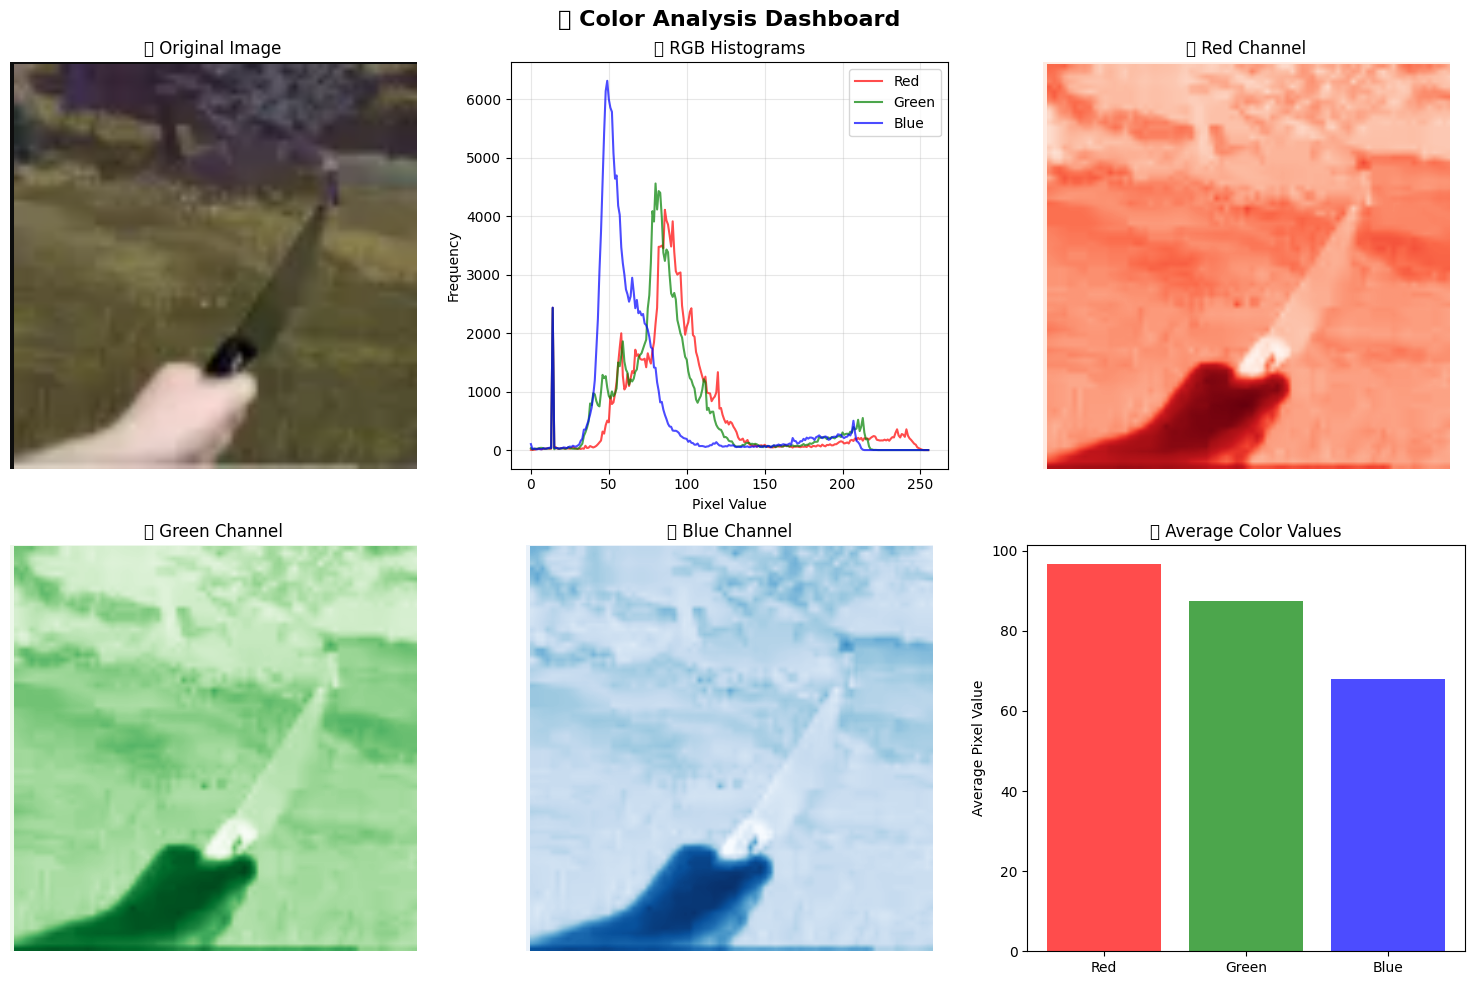

In [13]:
# Color Analysis and Visualization
if pil_img is not None:
    print("🎨 COLOR ANALYSIS")
    print("=" * 40)
    
    # Debug: Check image array shape
    print(f"🔍 Debug - Image array shape: {img_array.shape}")
    print(f"🔍 Debug - PIL image mode: {pil_img.mode}")
    
    # Ensure we have RGB format (3 channels only)
    if len(img_array.shape) == 3 and img_array.shape[2] == 4:
        print("🔄 Removing alpha channel from array...")
        img_array = img_array[:, :, :3]  # Keep only RGB channels
        print(f"✅ New shape: {img_array.shape}")
    
    # Create color analysis dashboard
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('🎨 Color Analysis Dashboard', fontsize=16, fontweight='bold')
    
    # Original image
    axes[0, 0].imshow(img_array)
    axes[0, 0].set_title('📸 Original Image')
    axes[0, 0].axis('off')
    
    if len(img_array.shape) == 3 and img_array.shape[2] == 3:  # RGB color image
        # RGB Histograms
        colors = ['red', 'green', 'blue']
        for i, color in enumerate(colors):
            hist = cv2.calcHist([img_array], [i], None, [256], [0, 256])
            axes[0, 1].plot(hist, color=color, alpha=0.7, label=f'{color.capitalize()}')
        
        axes[0, 1].set_title('📊 RGB Histograms')
        axes[0, 1].set_xlabel('Pixel Value')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # Color channel separation
        axes[0, 2].imshow(img_array[:, :, 0], cmap='Reds')
        axes[0, 2].set_title('🔴 Red Channel')
        axes[0, 2].axis('off')
        
        axes[1, 0].imshow(img_array[:, :, 1], cmap='Greens')
        axes[1, 0].set_title('🟢 Green Channel')
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(img_array[:, :, 2], cmap='Blues')
        axes[1, 1].set_title('🔵 Blue Channel')
        axes[1, 1].axis('off')
        
        # Color statistics - ensure only 3 channels
        mean_colors = np.mean(img_array, axis=(0, 1))
        print(f"🔍 Debug - mean_colors shape: {mean_colors.shape}")
        print(f"🔍 Debug - mean_colors values: {mean_colors}")
        
        # Make sure we only have 3 values
        if len(mean_colors) > 3:
            mean_colors = mean_colors[:3]
        
        axes[1, 2].bar(['Red', 'Green', 'Blue'], mean_colors, 
                      color=['red', 'green', 'blue'], alpha=0.7)
        axes[1, 2].set_title('📈 Average Color Values')
        axes[1, 2].set_ylabel('Average Pixel Value')
        
        print(f"🔴 Red   - Mean: {mean_colors[0]:.1f}")
        print(f"🟢 Green - Mean: {mean_colors[1]:.1f}")
        print(f"🔵 Blue  - Mean: {mean_colors[2]:.1f}")
        
    else:  # Grayscale or other format
        print(f"⚠️  Non-standard image format detected")
        if len(img_array.shape) == 2:  # Grayscale
            hist = cv2.calcHist([img_array], [0], None, [256], [0, 256])
            axes[0, 1].plot(hist, color='gray')
            axes[0, 1].set_title('📊 Grayscale Histogram')
        else:
            # Convert to grayscale for analysis
            gray_img = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY) if len(img_array.shape) == 3 else img_array
            hist = cv2.calcHist([gray_img], [0], None, [256], [0, 256])
            axes[0, 1].plot(hist, color='gray')
            axes[0, 1].set_title('📊 Converted Grayscale Histogram')
        
        axes[0, 1].set_xlabel('Pixel Value')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Hide unused subplots
        for i in range(2):
            for j in range(2, 3):
                axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ No image loaded for color analysis")

In [ ]:
# Comprehensive Analysis Summary
if pil_img is not None:
    print("📊 COMPREHENSIVE ANALYSIS REPORT")
    print("=" * 50)
    
    # Convert to grayscale for analysis
    if len(img_array.shape) == 3:
        gray_img = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    else:
        gray_img = img_array.copy()
    
    # Image quality metrics
    sharpness = cv2.Laplacian(gray_img, cv2.CV_64F).var()
    brightness = np.mean(gray_img)
    contrast = np.std(gray_img)
    
    # Information entropy
    hist, _ = np.histogram(gray_img, bins=256, range=(0, 256))
    hist = hist / hist.sum()
    entropy = -np.sum(hist * np.log2(hist + 1e-10))
    
    print(f"📁 File: {IMAGE_KEY}")
    print(f"📏 Size: {pil_img.size[0]} × {pil_img.size[1]} pixels")
    print(f"💾 File size: {len(image_data):,} bytes")
    print(f"🎨 Color mode: {pil_img.mode}")
    print()
    print("🔍 QUALITY METRICS:")
    print(f"  • Sharpness: {sharpness:.1f}")
    print(f"  • Brightness: {brightness:.1f}/255 ({brightness/255*100:.1f}%)")
    print(f"  • Contrast: {contrast:.1f}")
    print(f"  • Entropy: {entropy:.2f} bits")
    print()
    print("📈 ANALYSIS:")
    
    if brightness < 85:
        print("  • 🌙 Dark image - consider brightness adjustment")
    elif brightness > 170:
        print("  • ☀️ Bright image - well illuminated")
    else:
        print("  • 🌤️ Well-balanced brightness")
    
    if contrast < 32:
        print("  • 📉 Low contrast - image may appear flat")
    elif contrast > 96:
        print("  • 📈 High contrast - strong variation")
    else:
        print("  • ⚖️ Good contrast balance")
    
    if sharpness < 100:
        print("  • 😵‍💫 Potentially blurry image")
    elif sharpness > 500:
        print("  • 🔍 Very sharp with fine details")
    else:
        print("  • 👁️ Reasonably sharp image")
    
    print(f"\n✅ Analysis completed successfully!")
    print(f"🗂️ Image source: MinIO bucket '{BUCKET_NAME}'")
    
    # Create simple quality visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Quality metrics bar chart
    metrics = ['Sharpness\n(/1000)', 'Brightness\n(/255)', 'Contrast\n(/128)', 'Entropy\n(/8)']
    values = [sharpness/1000, brightness/255, contrast/128, entropy/8]
    colors = ['red', 'orange', 'green', 'blue']
    
    bars = ax1.bar(metrics, values, color=colors, alpha=0.7)
    ax1.set_title('📊 Image Quality Metrics')
    ax1.set_ylabel('Normalized Score')
    ax1.set_ylim(0, 1)
    
    # Add value labels
    for bar, val in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.2f}', ha='center', va='bottom')
    
    # Intensity histogram
    ax2.hist(gray_img.ravel(), bins=50, alpha=0.7, color='gray')
    ax2.axvline(brightness, color='red', linestyle='--', label=f'Mean: {brightness:.0f}')
    ax2.set_title('📈 Intensity Distribution')
    ax2.set_xlabel('Pixel Intensity')
    ax2.set_ylabel('Frequency')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ No image loaded for comprehensive analysis")